In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [ ]:
import math
import keyring
import itertools

In [5]:
# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

In [6]:
# read in the data
# df = pd.read_csv(data_dir + "/data_processed/tbi_merged.csv")
df = pd.read_csv("../../data_processing/tbi_cleaned.csv")
df

C:\Users\yianz\AppData\Local\Temp\ipykernel_21280\2582001599.py:3: DtypeWarning: Columns (33,34,35,52,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data_processing/tbi_cleaned.csv")


,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight
0,0,1,18112062,1811206201,1,1,1.0,[1811206201001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
1,1,1,18112062,1811206201,1,1,2.0,[1811206201002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
2,2,1,18112062,1811206203,3,1,1.0,[1811206203001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
3,3,1,18112062,1811206203,3,1,2.0,[1811206203002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
4,4,1,18112062,1811206204,4,1,1.0,[1811206204001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455179,512248,2,22002790,2200279003,3,1,212556.0,[2200279003003],2022-01-27,Thursday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,20.910320,20.910320,20.910320,32.363497
455180,512249,2,22002791,2200279101,1,1,212557.0,[2200279101001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
455181,512250,2,22002791,2200279101,1,1,212558.0,[2200279101002],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
455182,512251,2,22002791,2200279102,2,1,212559.0,[2200279102001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499


In [69]:
def plot_density(column: pd.Series, percentile=0.95, discrete=False, bins=100, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    sns.histplot(column, ax=ax, discrete=discrete, bins=bins, kde=True, stat="density")
    val = column.quantile(q=percentile)
    plt.axvline(x=val, color="red")
    return fig, ax

In [8]:
# duration analysis

In [61]:
## overall analysis
df["duration"].describe()

count    455184.000000
mean         19.273859
std          22.771212
min           0.100000
25%           8.250000
50%          13.983333
75%          23.033333
max         970.516667
Name: duration, dtype: float64

(0.0, 200.0)

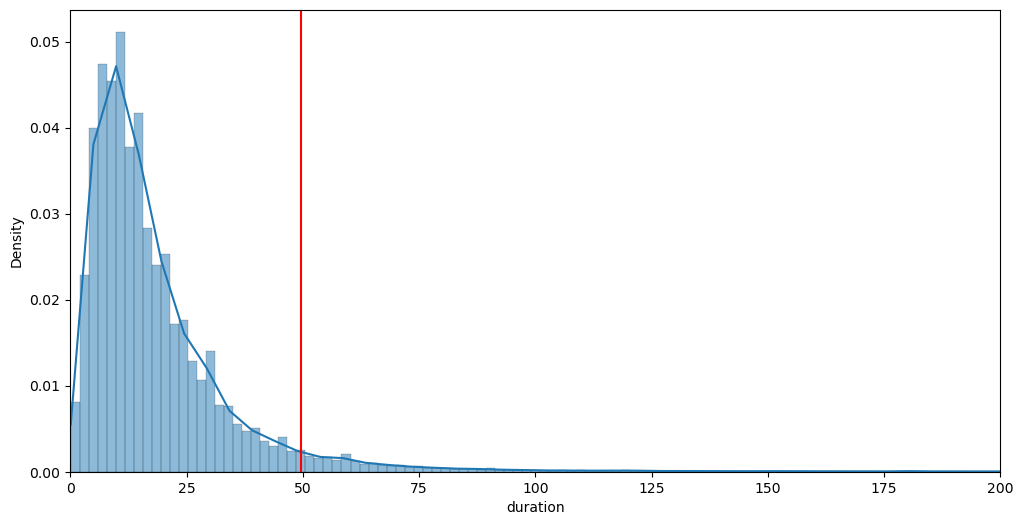

In [70]:
### overall distribution of duration
fig, ax = plot_density(df["duration"], bins=500)
ax.set_xlim(left=0, right=200) # cutoff upper end, there are some outliers that make the graph hard to read

In [43]:
### 95th percentile of linked trip duration -- 49.7 minutes
df["duration"].quantile(0.95)

49.7

Text(0.5, 0, 'log duration')

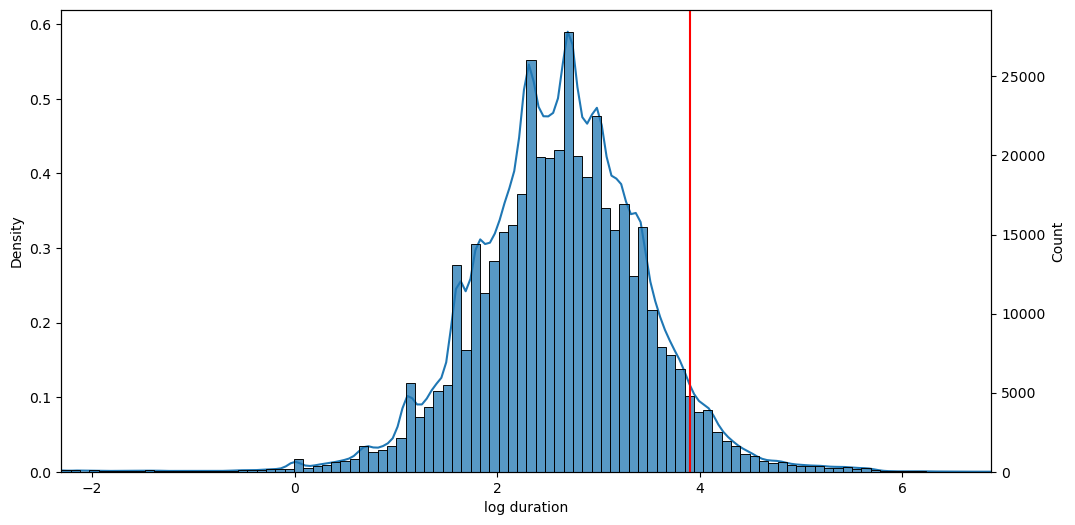

In [40]:
### overall distribution of the log of duration
fig, ax = plot_density(np.log(df["duration"]), bins=100)
ax.set_xlabel("log duration")

In [ ]:
## duration analysis segmented by mode

In [50]:
df["mode"].value_counts()

Car                       380543
Walk                       50134
Transit                    11279
Bike/Scooter                7705
School bus                  3668
Taxi/Ridehail/Carshare      1855
Name: mode, dtype: int64

In [53]:
# currently ignore schools bus and taxi/ridehail/carshare -- can decide whether to omit or group with others later
# with school buses, we might need analysis for school-age children only since school buses aren't a widely available mode to the public
# with taxi/ridehail/carshare, could be transit but it is very distinct, possibly omit or add as another option
df_mode_cleaned = df[~df["mode"].isin(["School bus", "Taxi/Ridehail/Carshare"])]

In [97]:
palette = itertools.cycle(sns.color_palette())
def plot_mode_density(df: pd.DataFrame, key: str, percentile=0.95, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    for mode in df["mode"].value_counts().index:
        c = next(palette)
        group = df[df["mode"] == mode]
        sns.histplot(group[key], ax=ax, stat="density", kde=True, label=mode, color=c)
        val = group[key].quantile(q=percentile)
        plt.axvline(x=val, color=c)
    return fig, ax

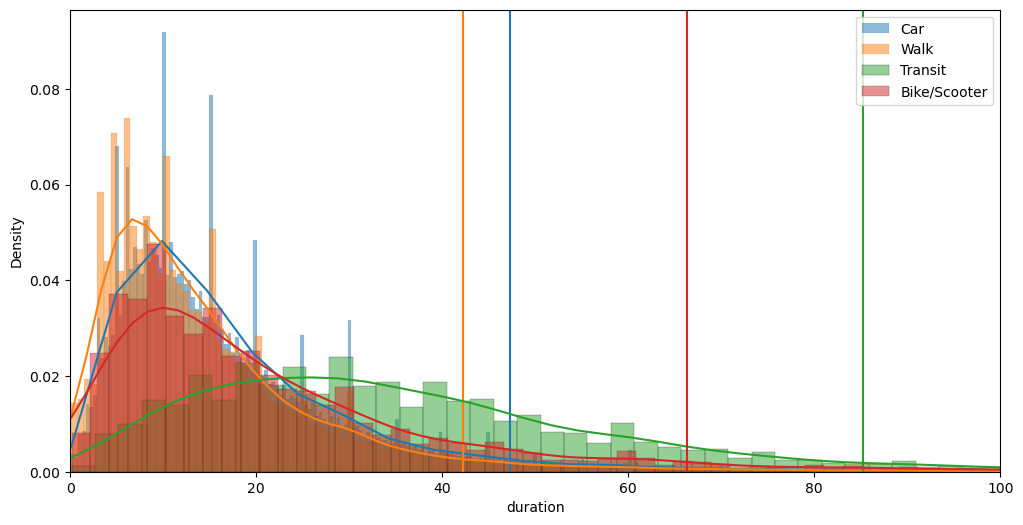

In [98]:
fig, ax = plot_mode_density(df_mode_cleaned, "duration")
ax.set_xlim(left=0, right=100)
plt.legend()

In [ ]:
### car duration

In [48]:
df.columns

Index(['Unnamed: 0', 'wave', 'hh_id', 'person_id', 'person_num', 'day_num',
       'linked_trip_id', 'trip_id', 'travel_date', 'travel_dow', 'depart_time',
       'arrive_time', 'duration', 'distance', 'speed_mph', 'vehicle_trips',
       'vmt', 'o_lat', 'o_lon', 'o_bg_2010', 'o_county', 'o_state', 'd_lat',
       'd_lon', 'd_bg_2010', 'd_county', 'd_state', 'mode', 'detailed_mode',
       'o_purpose', 'o_purpose_category', 'd_purpose', 'd_purpose_category',
       'num_travelers', 'num_hh_travelers', 'num_non_hh_travelers',
       'num_unlinked_trips', 'gas_link', 'home_lat', 'home_lon',
       'home_bg_2010', 'home_county', 'home_state', 'income_broad',
       'income_detailed', 'rent_own', 'rent_cost', 'residence_type',
       'num_adults', 'num_kids', 'num_students', 'num_workers', 'num_vehicles',
       'relationship', 'age', 'gender', 'disability', 'education',
       'student_status', 'school_attend', 'employment_status', 'num_jobs',
       'job_type', 'can_drive', 'transportati

In [49]:
df.detailed_mode.value_counts()

Household vehicle                      240547
Vehicle                                126084
Walk                                    50134
Other vehicle                           13912
Public bus                               5135
Micromobility                            4527
School bus                               3668
Bicycle or e-bicycle                     3124
Transit                                  2736
Rail                                     2188
Other bus                                1088
Smartphone ridehailing service            875
Smartphone-app ride-hailing service       652
For-hire vehicle                          139
Shuttle                                   132
Taxi                                      108
Carshare                                   81
Bike-share                                 41
Scooter-share                              13
Name: detailed_mode, dtype: int64

In [ ]:
### overall distribution of duration
fig, ax = plot_density(df["duration"], bins=500)
ax.set_xlim(left=0, right=200) # cutoff upper end, there are some outliers that make the graph hard to read